In [1]:
from openbb import obb
from os import environ

obb.account.login(pat= environ.get('OBB_TOKEN'))
cdr = obb.equity.price.historical('CDR.WA', start_date = '2000-01-01', provider='yfinance').to_df()
dq = 0.25
cdr.iloc[:, :5] = cdr.iloc[:, :5].mul(dq)
cdr.columns = cdr.columns.str.lower()
display(cdr.head())


,open,high,low,close,volume,dividends,stock splits
date,,,,,,,
2000-01-03,9.2325,9.7125,9.1900,9.7125,11503.25,0.0,0.0
2000-01-04,9.3975,9.6600,9.3975,9.5025,22683.75,0.0,0.0
2000-01-05,9.3475,9.4925,9.2950,9.4500,13572.75,0.0,0.0
2000-01-06,9.4300,9.6600,9.4300,9.4925,16922.25,0.0,0.0
2000-01-07,10.1300,10.8600,10.1300,10.8600,16793.00,0.0,0.0


In [2]:
obb.equity.fundamental.metrics('cdr.wa', limit=1).to_df()
df = obb.equity.fundamental.metrics('cdr.wa', limit=1).to_df()
df.set_index('symbol', inplace=True)
df = df.transpose()
display(df)


symbol,CDR.WA
market_cap,13060123781.879999
pe_ratio,37.62716
period,FY
calendar_year,2022
revenue_per_share,9.455649
net_income_per_share,3.445384
operating_cash_flow_per_share,4.030426
free_cash_flow_per_share,1.488225
cash_per_share,8.880871
book_value_per_share,20.184379


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
# Filter the dataframe to include only dates before '2020-08-27'
cdr_before_2020 = cdr[cdr.index < '2020-08-27']

# Extract the 'Close' column values as a numpy array
closes = cdr_before_2020[['close']].values

# Normalize the data using StandardScaler
sc = MinMaxScaler()

X = sc.fit_transform(closes)

In [4]:
# split into samples
X_samples = list()
y_samples = list()
 
NumerOfRows = len(X)
TimeSteps=20  # next few day's Price Prediction is based on last how many past day's prices
FutureTimeSteps=120 # How many days in future you want to predict the prices
 
# Iterate thru the values to create combinations
for i in range(TimeSteps , NumerOfRows-FutureTimeSteps , 1):
    x_sample = X[i-TimeSteps:i]
    y_sample = X[i:i+FutureTimeSteps]
    X_samples.append(x_sample)
    y_samples.append(y_sample)
 
################################################
 
# Reshape the Input as a 3D (samples, Time Steps, Features)
X_data=np.array(X_samples)
X_data=X_data.reshape(X_data.shape[0],X_data.shape[1], 1)
print('### Input Data Shape ###') 
print(X_data.shape)
 
# We do not reshape y as a 3D data  as it is supposed to be a single column only
y_data=np.array(y_samples)
print('### Output Data Shape ###') 
print(y_data.shape)

### Input Data Shape ###
(5194, 20, 1)
### Output Data Shape ###
(5194, 120, 1)


In [5]:
TestingRecords=40
 
# Splitting the data into train and test
X_train=X_data[:-TestingRecords]
X_test=X_data[-TestingRecords:]
y_train=y_data[:-TestingRecords]
y_test=y_data[-TestingRecords:]
 
#############################################
# Printing the shape of training and testing
print('\n#### Training Data shape ####')
print(X_train.shape)
print(y_train.shape)
 
print('\n#### Testing Data shape ####')
print(X_test.shape)
print(y_test.shape)


#### Training Data shape ####
(5154, 20, 1)
(5154, 120, 1)

#### Testing Data shape ####
(40, 20, 1)
(40, 120, 1)


In [6]:

# Defining Input shapes for LSTM
TimeSteps=X_train.shape[1]
TotalFeatures=X_train.shape[2]
print("Number of TimeSteps:", TimeSteps)
print("Number of Features:", TotalFeatures)

Number of TimeSteps: 20
Number of Features: 1


In [25]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
 
# Initialising the RNN
regressor = Sequential()
 
# Adding the First input hidden layer and the LSTM layer
# return_sequences = True, means the output of every time step to be shared with hidden next layer
regressor.add(LSTM(units = 10, activation = 'relu', input_shape = (TimeSteps, TotalFeatures), return_sequences=True))
 
 
# Adding the Second hidden layer and the LSTM layer
regressor.add(LSTM(units = 5, activation = 'relu', input_shape = (TimeSteps, TotalFeatures), return_sequences=True))
 
# Adding the Third hidden layer and the LSTM layer
regressor.add(LSTM(units = 5, activation = 'relu', return_sequences=False ))
 
 
# Adding the output layer
# Notice the number of neurons in the dense layer is now the number of future time steps 
# Based on the number of future days we want to predict
regressor.add(Dense(units = FutureTimeSteps))
 
# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')
 
###################################################################
 
import time
# Measuring the time taken by the model to train
StartTime=time.time()
 
# Fitting the RNN to the Training set
regressor.fit(X_train, y_train, epochs = 15)
 
EndTime=time.time()
print("############### Total Time Taken: ", round((EndTime-StartTime)/60), 'Minutes #############')

Epoch 1/15
162/162 [==============================] - 5s 13ms/step - loss: 0.0182
Epoch 2/15
162/162 [==============================] - 2s 14ms/step - loss: 0.0016
Epoch 3/15
162/162 [==============================] - 3s 16ms/step - loss: 0.0012
Epoch 4/15
162/162 [==============================] - 3s 16ms/step - loss: 0.0012
Epoch 5/15
162/162 [==============================] - 2s 15ms/step - loss: 0.0012
Epoch 6/15
162/162 [==============================] - 2s 13ms/step - loss: 0.0012
Epoch 7/15
162/162 [==============================] - 2s 12ms/step - loss: 0.0011
Epoch 8/15
162/162 [==============================] - 2s 14ms/step - loss: 0.0012
Epoch 9/15
162/162 [==============================] - 2s 12ms/step - loss: 0.0012
Epoch 10/15
162/162 [==============================] - 2s 13ms/step - loss: 0.0012
Epoch 11/15
162/162 [==============================] - 3s 19ms/step - loss: 0.0012
Epoch 12/15
162/162 [==============================] - 2s 15ms/step - loss: 0.0012
Epoch 13/15
1

In [9]:
predicted_Price = regressor.predict(X_test)
predicted_Price = sc.inverse_transform(predicted_Price)
print('#### Predicted Prices ####')
print(predicted_Price)

# Getting the original price values for testing data
orig = y_test.reshape(y_test.shape[0], y_test.shape[1])
orig = sc.inverse_transform(orig)
print('\n#### Original Prices ####')
print(orig)

2/2 [==============================] - 0s 7ms/step
#### Predicted Prices ####
[[ 70.8937    71.04594   71.355675 ...  86.94907   87.166466  87.64374 ]
 [ 71.28378   71.43638   71.747795 ...  87.44563   87.66439   88.14463 ]
 [ 71.55639   71.70924   72.02182  ...  87.792625  88.012344  88.49466 ]
 ...
 [ 88.05404   88.221855  88.60543  ... 108.79314  109.07075  109.67871 ]
 [ 86.95772   87.12454   87.503395 ... 107.3976   107.67136  108.27097 ]
 [ 85.67987   85.84552   86.21889  ... 105.770966 106.040245 106.63013 ]]

#### Original Prices ####
[[ 70.575  66.625  70.375 ... 100.4    98.725 100.8  ]
 [ 66.625  70.375  69.7   ...  98.725 100.8   101.225]
 [ 70.375  69.7    68.9   ... 100.8   101.225 101.5  ]
 ...
 [ 67.5    67.575  62.75  ... 103.75  102.15  102.3  ]
 [ 67.575  62.75   54.025 ... 102.15  102.3   103.65 ]
 [ 62.75   54.025  60.975 ... 102.3   103.65  102.   ]]


In [26]:
# Making predictions on test data
Last10DaysPrices=np.array(cdr_before_2020.tail(20)['close'])
# Reshaping the data to (-1,1 )because its a single entry
Last10DaysPrices=Last10DaysPrices.reshape(-1, 1)
 
# Scaling the data on the same level on which model was trained
X_test=sc.transform(Last10DaysPrices)
 
NumberofSamples=1
TimeSteps=X_test.shape[0]
NumberofFeatures=X_test.shape[1]
# Reshaping the data as 3D input
X_test=X_test.reshape(NumberofSamples,TimeSteps,NumberofFeatures)
 
# Generating the predictions for next 5 days
Next120DaysPrice = regressor.predict(X_test)
 
# Generating the prices in original scale
Next120DaysPrice = sc.inverse_transform(Next120DaysPrice)
forecast = Next120DaysPrice.flatten()
import pandas as pd
forecast = pd.DataFrame(forecast, index=pd.date_range(start='2020-08-27', periods=120, freq='D'), columns=['close'])
forecast

1/1 [==============================] - 1s 670ms/step


,close
2020-08-27,122.155930
2020-08-28,120.315041
2020-08-29,128.917618
2020-08-30,121.994026
2020-08-31,128.403854
...,...
2020-12-20,141.233597
2020-12-21,148.673828
2020-12-22,155.075684
2020-12-23,148.550491


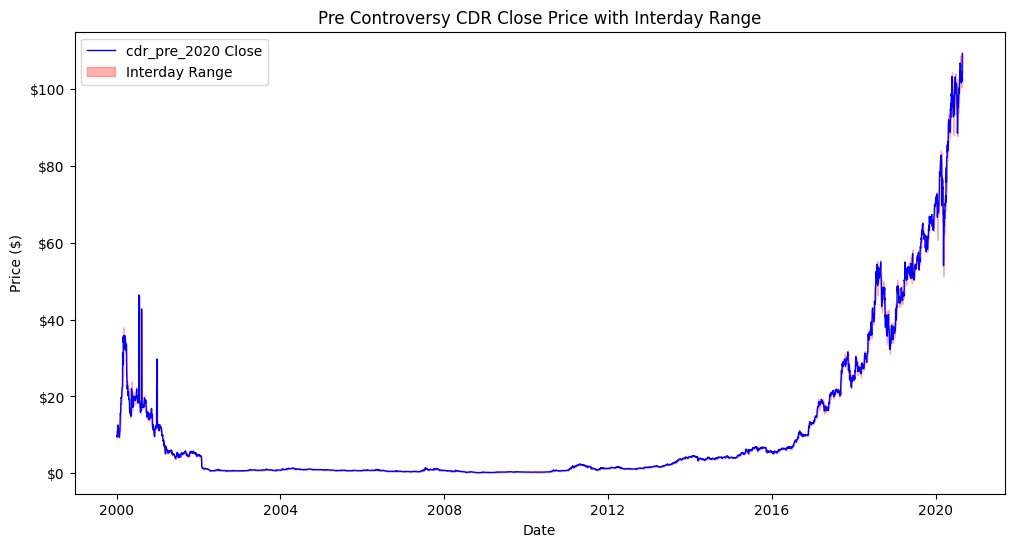

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the light theme
plt.style.use('seaborn-v0_8-bright')

# Set the figure size
plt.figure(figsize=(12, 6))

# Plot the cdr_pre_2020 close prices
plt.plot(cdr_before_2020.index, cdr_before_2020['close'], label='cdr_pre_2020 Close', color='blue', linewidth=1)

# Plot the interday range as an area between the high and low lines
plt.fill_between(cdr_before_2020.index, cdr_before_2020['low'], cdr_before_2020['high'], color='red', alpha=0.3, label='Interday Range')

# Set the x-axis label
plt.xlabel('Date')

# Set the y-axis label
plt.ylabel('Price ($)')

# Set the title of the plot
plt.title('Pre Controversy CDR Close Price with Interday Range')

# Format the y-axis tick labels to display dollars
plt.gca().yaxis.set_major_formatter('${:,.0f}'.format)

# Add a legend
plt.legend()

# Show the plot
plt.show()


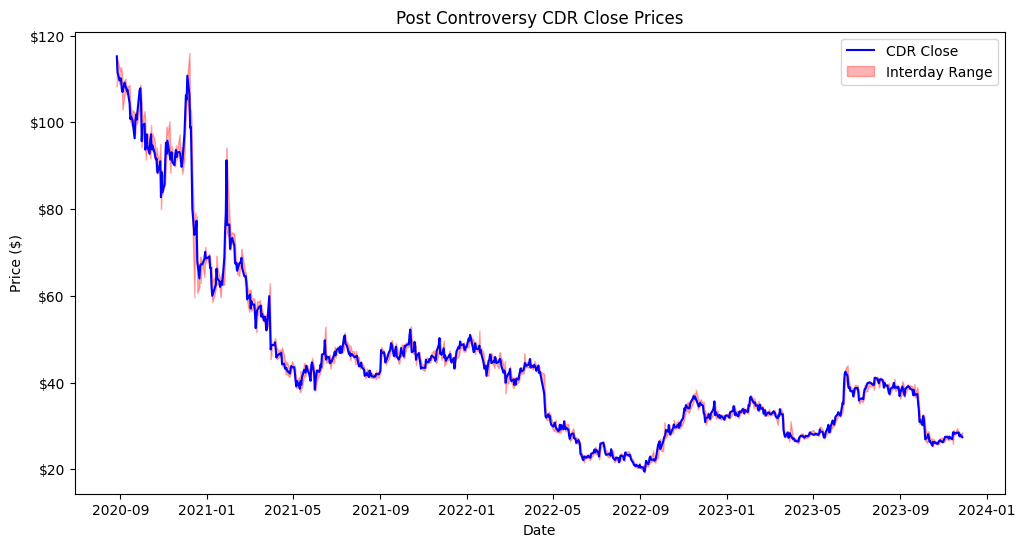

In [12]:
# Filter the dataframe to include dates starting from '2016-01-01'
cdr_from_2016 = cdr[cdr.index >= '2020-08-27']

# Set the light theme
plt.style.use('seaborn-v0_8-bright')

# Set the figure size
plt.figure(figsize=(12, 6))

# Plot the cdr_from_2016 close prices
plt.plot(cdr_from_2016.index, cdr_from_2016['close'], label='CDR Close', color='blue')

plt.fill_between(cdr_from_2016.index, cdr_from_2016['low'], cdr_from_2016['high'], color='red', alpha=0.3, label='Interday Range')
# Set the x-axis label
plt.xlabel('Date')

# Set the y-axis label
plt.ylabel('Price ($)')

# Set the title of the plot
plt.title('Post Controversy CDR Close Prices')

# Format the y-axis tick labels to display dollars
plt.gca().yaxis.set_major_formatter('${:,.0f}'.format)

plt.legend()
# Show the plot
plt.show()


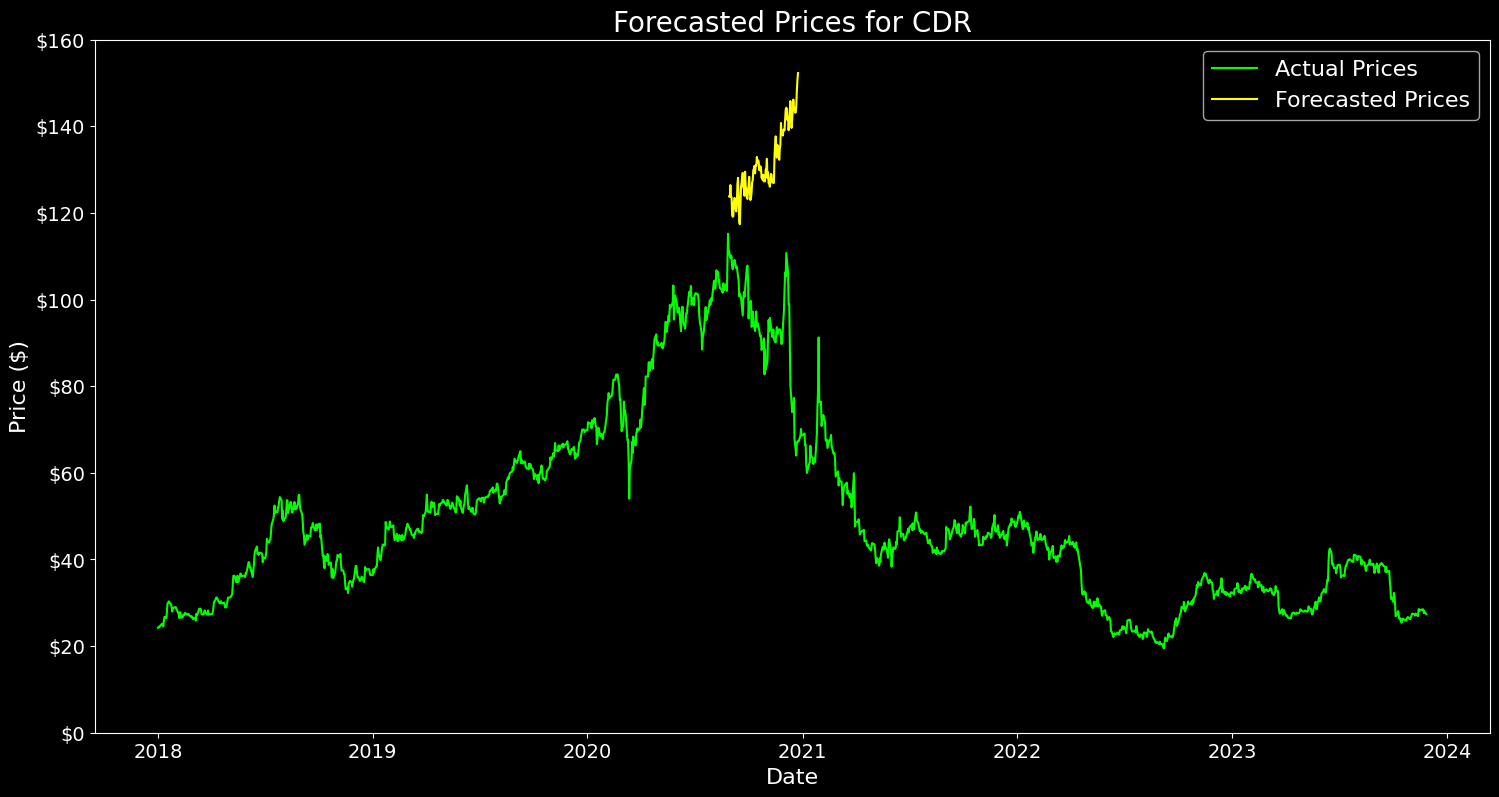

In [29]:
# Set the dark theme
plt.style.use('dark_background')

# Set the font to Myriad Pro
plt.rcParams['font.family'] = 'Myriad Pro'

# Get the dates for the forecast period
forecast_start_date = '2018-01-01'

# Filter the actual prices dataframe to include dates starting from 2018
actual_prices = cdr[cdr.index >= forecast_start_date]

# Filter the forecasted prices dataframe to include dates starting from 2018
forecast_prices = forecast[forecast.index >= forecast_start_date].rolling(3).mean()

plt.figure(figsize=(18, 9))
# Plot the actual prices with higher contrast line color
plt.plot(actual_prices.index, actual_prices['close'], label='Actual Prices', color='lime')

# Plot the forecasted prices with higher contrast line color
plt.plot(forecast_prices.index, forecast_prices['close'], label='Forecasted Prices', color='yellow')

# Set the x-axis label
plt.xlabel('Date', fontsize=16)

# Set the y-axis label
plt.ylabel('Price ($)', fontsize=16)

# Set the title of the plot
plt.title('Forecasted Prices for CDR', fontsize=20)

# Add a legend
plt.legend()

# Set the y-axis tick labels to display dollars
plt.yticks(ticks=plt.yticks()[0], labels=['${:,.0f}'.format(x) for x in plt.yticks()[0]], fontsize=14)

# Set the x-axis tick labels font size
plt.xticks(fontsize=14)

plt.legend(fontsize=16)
# Show the plot
plt.show()


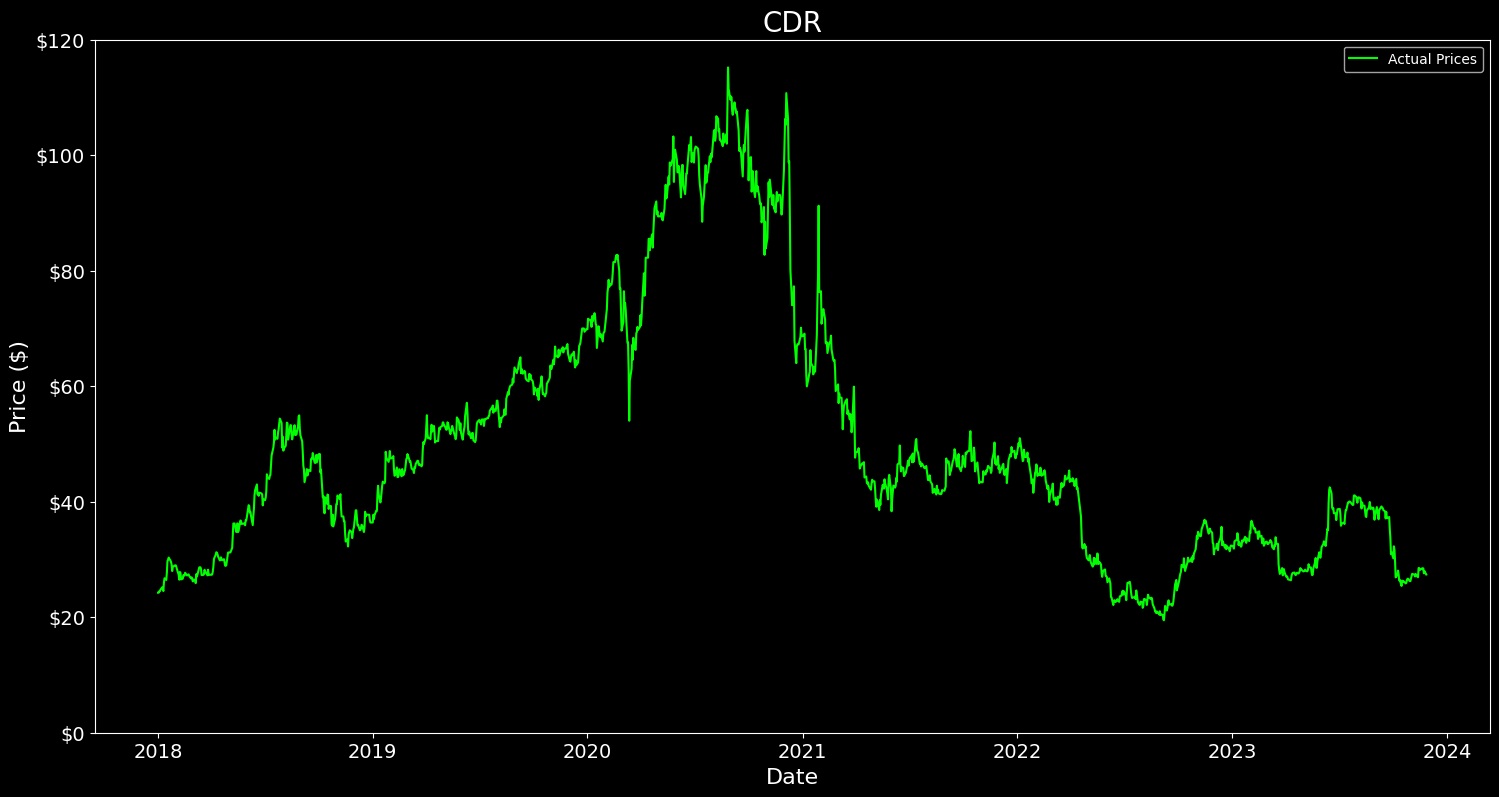

In [16]:
forecast_start_date = '2018-01-01'

# Filter the actual prices dataframe to include dates starting from 2018
actual_prices = cdr[cdr.index >= forecast_start_date]

# Filter the forecasted prices dataframe to include dates starting from 2018
forecast_prices = forecast[forecast.index >= forecast_start_date].rolling(3).mean()

plt.figure(figsize=(18, 9))
# Plot the actual prices with higher contrast line color
plt.plot(actual_prices.index, actual_prices['close'], label='Actual Prices', color='lime')

# Set the x-axis label
plt.xlabel('Date', fontsize=16)

# Set the y-axis label
plt.ylabel('Price ($)', fontsize=16)

# Set the title of the plot
plt.title('CDR', fontsize=20)

# Add a legend
plt.legend()

# Set the y-axis tick labels to display dollars
plt.yticks(ticks=plt.yticks()[0], labels=['${:,.0f}'.format(x) for x in plt.yticks()[0]], fontsize=14)

# Set the x-axis tick labels font size
plt.xticks(fontsize=14)

# Show the plot
plt.show() 

In [15]:
from decimal import Decimal

result = Decimal((forecast['close'].max() - actual_prices['close'].min()) * 100971014)
result


Decimal('22012604298.31392669677734375')